Verifikasi lingkungan kerja

In [1]:
import sys, platform, multiprocessing

print("Python :", sys.version.split()[0])
print("OS     :", platform.platform())
print("CPU    :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(nama)
    print(f"{nama:11s}: {mod.__version__}")
  except ImportError:
    print(f"{nama:11s}: BELUM TERPASANG")

Python : 3.13.15
OS     : Linux-6.6.122+-x86_64-with-glibc2.39
CPU    : 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [2]:
!free -h        # kapasitas dan sisa RAM
!df -h /content #kapasitas dan sisa disk runtime
!java -version  #dibutuhkan PySpark pada langkah k-8

               total        used        free      shared  buff/cache   available
Mem:            12Gi       936Mi       9.0Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.023s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.023s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


MenghubungkanGoogle Drivedanmenyiapkanstruktur folder

In [3]:
from google.colab import drive
try:
    drive.mount("/content/drive", force_remount=True)
except Exception as e:
    print("Proses mount menemui kendala:", e)

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/Colap Nootebook/Big Data/Praktikum1"

os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


Menyiapkanalat ukur waktu dan memori

In [4]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2), "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS delta: {delta:+.1f} MB")
    return hasil

Mengunduh dataset dan inspeksi awal

In [5]:
import urllib.request
URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

import pyarrow.parquet as pq
meta = pq.ParquetFile(PATH).metadata

print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

[unduh dataset] 0.35 s | RSS delta: +1.8 MB
Ukuran file: 45.5 MB
Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


Jalur cadangan bila unduhan gagal

In [6]:
import numpy as np, pandas as pd

def bangkitkan_sintetis(n=5_000_000, seed=42):
    rng = np.random.default_rng(seed)
    awal = pd.Timestamp("2023-01-01")
    pickup = awal + pd.to_timedelta(rng.integers(0, 31*24*60, n), unit="m")
    durasi = rng.integers(1, 90, n)
    return pd.DataFrame({
        "tpep_pickup_datetime": pickup,
        "tpep_dropoff_datetime": pickup + pd.to_timedelta(durasi, unit="m"),
        "passenger_count": rng.integers(1, 5, n).astype("float64"),
        "trip_distance": np.round(rng.gamma(2.0, 1.6, n), 2),
        "payment_type": rng.integers(1, 5, n).astype("int64"),
        "fare_amount": np.round(rng.gamma(4.0, 3.0, n), 2),
        "tip_amount": np.round(rng.gamma(1.5, 1.2, n), 2),
    }).assign(total_amount=lambda d: (d.fare_amount + d.tip_amount + 3.0).round(2))

if not os.path.exists(PATH):
    bangkitkan_sintetis().to_parquet(PATH, index=False)
    print("Dataset sintetis dibuat di", PATH)

 Memuat data dan mengukur biaya memorinya

In [7]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

df.head()
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")

df.dtypes

[baca semua kolom] 1.31 s | RSS delta: +482.3 MB
Dimensi: (3066766, 19)
Memori: 565.6 MB
[baca kolom terpilih] 0.57 s | RSS delta: +221.2 MB
Dimensi: (3066766, 8)
Memori: 187.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB
187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


Pemeriksaan kualitas data dan pembersihan(veracity)

In [8]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())

print("\nNilai kosong per kolom: \n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom: 
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)
3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


 Memproses file lebih besar dari memori dengan chunking

In [9]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}

    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())

    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 39.74 s | RSS delta: +5.2 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 3.88 s | RSS delta: +12.9 MB
2,986,911 baris | rata-rata total_amount = 27.33


Pendekatan terdistribusi: PySparklocal mode

In [10]:
!pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 16.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [11]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime")) - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

Spark: 3.5.1
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 2.72 s | RSS delta: +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_j

Agregasi akhir dengan pandas dan penyimpanan artefak

In [12]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


Visualisasi Hasil

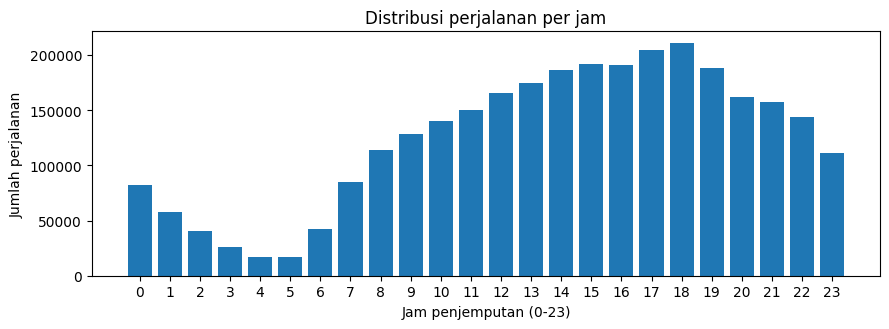

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

STUDI KASUS

In [14]:

bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"]/ bersih["durasi_menit"]).round(3)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2))

print("Tabel Studi Kasus O:")
display(ringkas.head(12))


# Latihan 1: 5 jarak terjauh
print("\nLatihan 1 - 5 Jarak Terjauh:")
display(bersih.nlargest(5, 'trip_distance'))

# Latihan 2: Chunking beda ukuran
print("\nLatihan 2 - Chunking Ukuran Beda:")
baris_100k, total_100k, p_100k = ukur("chunk 100k", lambda: agregasi_bertahap(CSV, 100_000))
baris_1m, total_1m, p_1m = ukur("chunk 1juta", lambda: agregasi_bertahap(CSV, 1_000_000))

# Latihan 3: Persen tip
print("\nLatihan 3 - Persen Tip:")
import numpy as np
bersih["persen_tip"] = np.where(bersih["fare_amount"] == 0, 0, (bersih["tip_amount"] / bersih["fare_amount"]) * 100)
display(bersih.groupby("payment_type")["persen_tip"].mean().round(2))

# Latihan 4: Kompresi Parquet
print("\nLatihan 4 - Bandingkan Kompresi Parquet:")
PATH_SNAPPY = os.path.join(DIR_SIMPAN, "bersih_snappy.parquet")
PATH_GZIP = os.path.join(DIR_SIMPAN, "bersih_gzip.parquet")
ukur("Simpan Snappy", lambda: bersih.to_parquet(PATH_SNAPPY, compression="snappy"))
ukur("Simpan Gzip", lambda: bersih.to_parquet(PATH_GZIP, compression="gzip"))
print("Ukuran Snappy:", round(os.path.getsize(PATH_SNAPPY) / 1024**2, 1), "MB")
print("Ukuran Gzip  :", round(os.path.getsize(PATH_GZIP) / 1024**2, 1), "MB")

Tabel Studi Kasus O:


jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86


Latihan 1 - 5 Jarak Terjauh:


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388



Latihan 2 - Chunking Ukuran Beda:
[chunk 100k] 9.35 s | RSS delta: +58.8 MB
[chunk 1juta] 3.90 s | RSS delta: +88.5 MB

Latihan 3 - Persen Tip:


/tmp/ipykernel_1047/3385751013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(bersih.groupby("payment_type")["persen_tip"].mean().round(2))


,persen_tip
payment_type,
0,20.219999
1,25.910000
2,0.000000
3,0.020000
4,0.150000



Latihan 4 - Bandingkan Kompresi Parquet:
[Simpan Snappy] 2.35 s | RSS delta: +16.4 MB
[Simpan Gzip] 69.58 s | RSS delta: +1.4 MB
Ukuran Snappy: 75.5 MB
Ukuran Gzip  : 56.0 MB


LATIHAN

Mengunduh dataset Februari 2023...


,jam,jumlah_Januari,jumlah_Februari
0,0,82289,75439
1,1,57766,49953
2,2,40445,34297
3,3,26146,22179
4,4,16618,14603
5,5,16940,15586
6,6,42300,40033
7,7,84569,79331
8,8,114064,109114
9,9,127988,123080


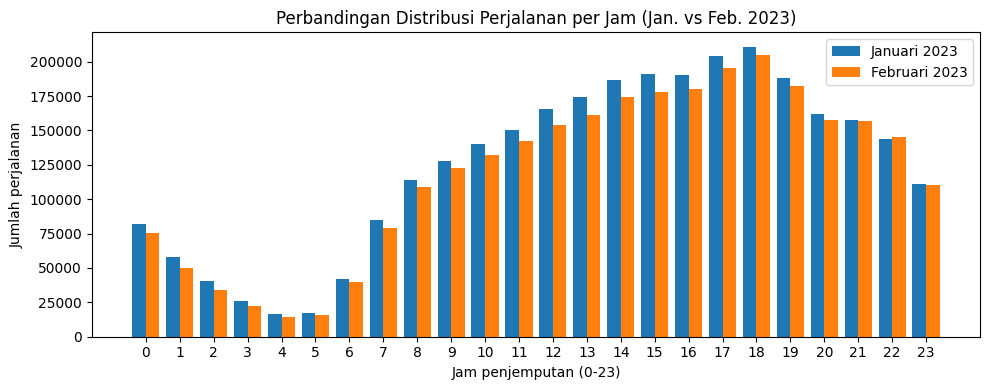

In [15]:
import urllib.request
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Mengunduh data Februari 2023
URL_FEB = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet"
PATH_FEB = os.path.join(DIR_KERJA, "yellow_tripdata_2023-02.parquet")

if not os.path.exists(PATH_FEB):
    print("Mengunduh dataset Februari 2023...")
    urllib.request.urlretrieve(URL_FEB, PATH_FEB)

# 2. Memuat dan membersihkan data Februari (seperti J-5 & J-6)
df_feb = pd.read_parquet(PATH_FEB, columns=KOLOM)
df_feb["durasi_menit"] = (df_feb["tpep_dropoff_datetime"] - df_feb["tpep_pickup_datetime"]).dt.total_seconds() / 60

layak_feb = (
    (df_feb["trip_distance"] > 0) & (df_feb["trip_distance"] < 100) &
    df_feb["durasi_menit"].between(1, 180) &
    (df_feb["total_amount"] > 0)
)
bersih_feb = df_feb.loc[layak_feb].copy()
bersih_feb["jam"] = bersih_feb["tpep_pickup_datetime"].dt.hour

# 3. Agregasi per jam bulan Februari
agregasi_feb = (bersih_feb
    .groupby("jam")
    .agg(jumlah_Februari=("total_amount", "size"))
    .reset_index())

# 4. Menggabungkan data Januari dan Februari
perbandingan = agregasi[["jam", "jumlah_perjalanan"]].rename(columns={"jumlah_perjalanan": "jumlah_Januari"})
perbandingan = perbandingan.merge(agregasi_feb, on="jam")

display(perbandingan)

# 5. Visualisasi Perbandingan
fig, ax = plt.subplots(figsize=(10, 4))
x = perbandingan["jam"]
w = 0.4
ax.bar(x - w/2, perbandingan["jumlah_Januari"], width=w, label="Januari 2023", color='#1f77b4')
ax.bar(x + w/2, perbandingan["jumlah_Februari"], width=w, label="Februari 2023", color='#ff7f0e')

ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Perbandingan Distribusi Perjalanan per Jam (Jan. vs Feb. 2023)")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_jan_feb.png", dpi=150)
plt.show()